In [1]:
%reload_ext autoreload
%autoreload 2
%cd /home/hazzu/Code/thesis
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

/home/hazzu/Code/thesis


In [2]:
OUTPUT_DIR = "results/compare-sfaces"

# 1. Load genuine và imposter pairs


In [3]:
import pandas as pd
import os.path as osp


def load_pairs():
    pairs_path = {
        "train": {
            "genuine_pairs": "datasets/ver1/selfies_2/genuine_pairs_train.csv",
            "imposter_pairs": "datasets/ver1/selfies_2/imposter_pairs_train.csv",
        },
        "test": {
            "genuine_pairs": "datasets/ver1/selfies_1/genuine_pairs_test.csv",
            "imposter_pairs": "datasets/ver1/selfies_1/imposter_pairs_test.csv",
        },
    }

    file_exists = all(
        [
            osp.exists(pairs_path[phase][pair_type])
            for phase in ["train", "test"]
            for pair_type in ["genuine_pairs", "imposter_pairs"]
        ]
    )

    pairs_data = {
        "train": {"genuine_pairs": None, "imposter_pairs": None},
        "test": {"genuine_pairs": None, "imposter_pairs": None},
    }
    if file_exists:
        print("LOADING --- Loading pairs from csv files")

        for phase in ["train", "test"]:
            for pair_type in ["genuine_pairs", "imposter_pairs"]:
                df = pd.read_csv(pairs_path[phase][pair_type])
                pairs_data[phase][pair_type] = list(
                    zip(df["image1_path"], df["image2_path"])
                )

        print("FINISHED --- Pairs loaded from csv files")
    else:
        print("File not found, please check the paths.")

    return pairs_data


pairs_data = load_pairs()

LOADING --- Loading pairs from csv files
FINISHED --- Pairs loaded from csv files


# 2. Tính cosine similarity


In [4]:
from tqdm import tqdm
import os, cv2, timeit
from lib.face_detector.yunet import YuNetDetector
from lib.face_recognizer.sface_custom import SFaceCustomRecognizer


def evaluate(sface_model: str, name: str, output_dir: str):
    face_detector = YuNetDetector()
    face_recognizer = SFaceCustomRecognizer(model_path=sface_model)

    PATH = os.path.join(output_dir, name)
    os.makedirs(PATH, exist_ok=True)

    for phase in ["train"]:
        for pair_type in ["genuine_pairs", "imposter_pairs"]:
            pair_data = pairs_data[phase][pair_type]

            results = []
            for image1_path, image2_path in tqdm(
                pair_data, desc=f"{phase}/{pair_type}"
            ):
                begin = timeit.default_timer()

                # Read images
                image1 = cv2.imread(image1_path)
                image2 = cv2.imread(image2_path)

                ################ [Don't use Image Pyramid] ######################
                # # Detect face in image1
                # scaled1 = min(400, image1.shape[0]) / image1.shape[0]
                # scaled_image1 = cv2.resize(image1, (0, 0), fx=scaled1, fy=scaled1)
                # _faces = face_detector.detect(scaled_image1)
                # if len(_faces) != 1:
                #     print(f"Cannot detect face in image {image1_path}")
                #     continue
                # face1 = _faces[0]

                # # Detect face in image2
                # scaled2 = min(400, image2.shape[0]) / image2.shape[0]
                # scaled_image2 = cv2.resize(image2, (0, 0), fx=scaled2, fy=scaled2)
                # _faces = face_detector.detect(scaled_image2)
                # if len(_faces) != 1:
                #     print(f"Cannot detect face in image {image2_path}")
                #     continue
                # face2 = _faces[0]
                ##################################################################

                ###################### [Use Image Pyramid] #######################
                # Detect face in image1
                face1, scale1 = face_detector.detect_single_multiscale(image1)
                if face1 is None:
                    print(f"Cannot detect face in card {image1_path}")
                    continue
                scaled_image1 = cv2.resize(
                    image1,
                    (int(scale1 * image1.shape[1]), int(scale1 * image1.shape[0])),
                )

                # Detect face in image2
                face2, scale2 = face_detector.detect_single_multiscale(image2)
                if face2 is None:
                    print(f"Cannot detect face in card {image2_path}")
                    continue
                scaled_image2 = cv2.resize(
                    image2,
                    (int(scale2 * image2.shape[1]), int(scale2 * image2.shape[0])),
                )
                ###################################################################

                # Find similarity of two faces
                similarity = face_recognizer.match(
                    scaled_image1, scaled_image2, face1, face2
                )

                # Calculate inference time
                end = timeit.default_timer()
                time = end - begin

                # Save result
                _face1 = [
                    face1.bbox["x"],
                    face1.bbox["y"],
                    face1.bbox["w"],
                    face1.bbox["h"],
                ]
                _face2 = [
                    face2.bbox["x"],
                    face2.bbox["y"],
                    face2.bbox["w"],
                    face2.bbox["h"],
                ]

                _face1 = [int(x / scale1) for x in _face1[:4]]
                _face2 = [int(x / scale2) for x in _face2[:4]]

                results.append(
                    (
                        image1_path,
                        image2_path,
                        *_face1,
                        *_face2,
                        similarity,
                        time,
                    )
                )

            # Save results to csv
            results_df = pd.DataFrame(
                results,
                columns=[
                    "image1_path",
                    "image2_path",
                    "face1_x",
                    "face1_y",
                    "face1_w",
                    "face1_h",
                    "face2_x",
                    "face2_y",
                    "face2_w",
                    "face2_h",
                    "similarity",
                    "inference_time",
                ],
            )

            results_df.to_csv(
                f"{PATH}/{pair_type}_{phase}.csv",
                index=False,
            )

In [5]:
# import torch
# from tqdm import tqdm
# import os, cv2, timeit
# from lib.cores.model_ae import AutoEncoderEncode
# from lib.face_detector.retinaface import RetinaFaceDetector
# from lib.face_recognizer.arcface import ArcFaceRecognizer

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# face_detector = RetinaFaceDetector()
# face_recognizer = ArcFaceRecognizer()
# ae_model = AutoEncoderEncode()
# ae_model.load_state_dict(
#     torch.load("weights/model_ae_epoch_300.pth", weights_only=True)
# )
# ae_model.eval()

# os.makedirs(f"results/compare-sfaces/retinaface_arcface_ae", exist_ok=True)

# for phase in ["train", "test"]:
#     for pair_type in ["genuine_pairs", "imposter_pairs"]:
#         pair_data = pairs_data[phase][pair_type]

#         results = []
#         for image1_path, image2_path in tqdm(pair_data, desc=f"{phase}/{pair_type}"):
#             begin = timeit.default_timer()

#             # Read images
#             image1 = cv2.imread(image1_path)
#             image2 = cv2.imread(image2_path)

#             scaled_image1 = image1
#             scaled_image2 = image2

#             # Detect face in image1
#             faces1 = face_detector.detect(scaled_image1)
#             if len(faces1) != 1:
#                 print(f"Cannot detect face in image {image1_path}")
#                 continue
#             face1 = faces1[0]

#             # Detect face in image2
#             faces2 = face_detector.detect(scaled_image2)
#             if len(faces2) != 1:
#                 print(f"Cannot detect face in image {image2_path}")
#                 continue
#             face2 = faces2[0]

#             # Find similarity of two faces
#             embed1 = face_recognizer.infer(scaled_image1, face1)
#             embed2 = face_recognizer.infer(scaled_image2, face2)
#             embed1 = ae_model(torch.Tensor(embed1))
#             embed2 = ae_model(torch.Tensor(embed2))
#             similarity = face_recognizer.similarity(
#                 embed1.detach().numpy(), embed2.detach().numpy()
#             )
#             # similarity = face_recognizer.match(
#             #     scaled_image1, scaled_image2, face1, face2
#             # )

#             # Calculate inference time
#             end = timeit.default_timer()
#             time = end - begin

#             # Save result
#             _face1 = [
#                 face1.bbox["x"],
#                 face1.bbox["y"],
#                 face1.bbox["w"],
#                 face1.bbox["h"],
#             ]
#             _face2 = [
#                 face2.bbox["x"],
#                 face2.bbox["y"],
#                 face2.bbox["w"],
#                 face2.bbox["h"],
#             ]

#             results.append(
#                 (
#                     image1_path,
#                     image2_path,
#                     *_face1,
#                     *_face2,
#                     similarity,
#                     time,
#                 )
#             )

#         # Save results to csv
#         results_df = pd.DataFrame(
#             results,
#             columns=[
#                 "image1_path",
#                 "image2_path",
#                 "face1_x",
#                 "face1_y",
#                 "face1_w",
#                 "face1_h",
#                 "face2_x",
#                 "face2_y",
#                 "face2_w",
#                 "face2_h",
#                 "similarity",
#                 "inference_time",
#             ],
#         )

#         results_df.to_csv(
#             f"results/compare-sfaces/retinaface_arcface_ae/{pair_type}_{phase}.csv",
#             index=False,
#         )

## 2.1. SFace (Baseline) (CASIA)


In [6]:
evaluate(
    # sface_model="weights/sface-baseline-casia.onnx",
    sface_model="weights/Backbone_MobileFaceNet.onnx",
    name="SFace (Baseline)",
    output_dir=OUTPUT_DIR,
)

train/imposter_pairs: 100%|██████████| 264/264 [00:26<00:00, 10.00it/s]


## 2.2. SFace + KD (SFace-OpenCV)


In [7]:
# evaluate(
#     sface_model="weights/sface-kd-sface-1.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.1)",
#     output_dir=OUTPUT_DIR,
# )

In [8]:
# evaluate(
#     sface_model="weights/sface-kd-sface-2.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.2)",
#     output_dir=OUTPUT_DIR,
# )

In [9]:
evaluate(
    # sface_model="weights/sface-kd-sface-3.onnx",
    sface_model="weights/Backbone_MobileFaceNet_KD_CE_03.onnx",
    name="SFace + KD (SFace-OpenCV) (0.3)",
    output_dir=OUTPUT_DIR,
)

train/imposter_pairs: 100%|██████████| 264/264 [00:26<00:00,  9.94it/s]


In [10]:
# evaluate(
#     sface_model="weights/sface-kd-sface-4.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.4)",
#     output_dir=OUTPUT_DIR,
# )

In [11]:
# evaluate(
#     sface_model="weights/sface-kd-sface-5.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.5)",
#     output_dir=OUTPUT_DIR,
# )

In [12]:
# evaluate(
#     sface_model="weights/sface-kd-sface-6.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.6)",
#     output_dir=OUTPUT_DIR,
# )

In [13]:
# evaluate(
#     sface_model="weights/sface-kd-sface-7.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.7)",
#     output_dir=OUTPUT_DIR,
# )

In [14]:
# evaluate(
#     sface_model="weights/sface-kd-sface-8.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.8)",
#     output_dir=OUTPUT_DIR,
# )

In [15]:
# evaluate(
#     sface_model="weights/sface-kd-sface-9.onnx",
#     name="SFace + KD (SFace-OpenCV) (0.9)",
#     output_dir=OUTPUT_DIR,
# )

## 2.3. SFace + KD (SFace-OpenCV) Finetuning


In [16]:
# evaluate(
#     sface_model="weights/sface-kd-sface-casia_real-ver2.onnx",
#     name="SFace + KD (SFace-OpenCV) Fine-tuning",
#     output_dir=OUTPUT_DIR,
# )

## 2.4. SFace + KD (ArcFace)


In [17]:
evaluate(
    sface_model="weights/Backbone_MobileFaceNet_KD_CE_ArcFace.onnx",
    name="SFace + KD (ArcFace)",
    output_dir=OUTPUT_DIR,
)

train/imposter_pairs: 100%|██████████| 264/264 [00:27<00:00,  9.43it/s]


# 3. Đánh giá


# 3.1. Tải kết quả


In [18]:
import pandas as pd

results_path = {
    "SFace (Baseline)": f"{OUTPUT_DIR}/SFace (Baseline)",
    "SFace + KD (SFace-OpenCV)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.3)",
    "SFace + KD (ArcFace)": f"{OUTPUT_DIR}/SFace + KD (ArcFace)",
    # "SFace + KD (SFace-OpenCV) (0.1)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.1)",
    # "SFace + KD (SFace-OpenCV) (0.2)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.2)",
    # "SFace + KD (SFace-OpenCV) (0.3)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.3)",
    # "SFace + KD (SFace-OpenCV) (0.4)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.4)",
    # "SFace + KD (SFace-OpenCV) (0.5)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.5)",
    # "SFace + KD (SFace-OpenCV) (0.6)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.6)",
    # "SFace + KD (SFace-OpenCV) (0.7)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.7)",
    # "SFace + KD (SFace-OpenCV) (0.8)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.8)",
    # "SFace + KD (SFace-OpenCV) (0.9)": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) (0.9)",
    # "SFace + KD (SFace-OpenCV) Fine-tuning": f"{OUTPUT_DIR}/SFace + KD (SFace-OpenCV) Fine-tuning",
}

results = {}
for key, value in results_path.items():
    results[key] = {
        "genuine_pairs_train": pd.read_csv(f"{value}/genuine_pairs_train.csv"),
        "genuine_pairs_test": pd.read_csv(f"{value}/genuine_pairs_test.csv"),
        "imposter_pairs_train": pd.read_csv(f"{value}/imposter_pairs_train.csv"),
        "imposter_pairs_test": pd.read_csv(f"{value}/imposter_pairs_test.csv"),
    }

## 3.2. Biểu đồ FAR và FRR


In [19]:
import numpy as np
from matplotlib import pyplot as plt


def calc_far_frr(genuine_pairs_similarity, imposter_pairs_similarity, threshold: float):
    genuine_pred = genuine_pairs_similarity >= threshold
    imposter_pred = imposter_pairs_similarity >= threshold

    false_accept = np.sum(imposter_pred)
    false_reject = np.sum(genuine_pred == False)

    far = false_accept / len(imposter_pred)
    frr = false_reject / len(genuine_pred)

    return (far, frr)


def display_far_frr(
    genuine_pairs_similarity, imposter_pairs_similarity, name: str, type: str = "train"
):
    thresholds = np.linspace(0, 1, 1000)
    far_frr = [
        calc_far_frr(genuine_pairs_similarity, imposter_pairs_similarity, threshold)
        for threshold in thresholds
    ]
    far_frr = np.array(far_frr)

    idx = (
        thresholds.shape[0] - np.argmin(np.abs(far_frr[:, 0] - far_frr[:, 1])[::-1]) - 1
    )
    thres = thresholds[idx]
    err = (far_frr[idx, 0] + far_frr[idx, 1]) / 2

    fig, ax = plt.subplots()
    fig.set_figwidth(4)
    fig.set_figheight(4)
    ax.plot(thresholds, far_frr[:, 0], label="False Accept Rate (FAR)")
    ax.plot(thresholds, far_frr[:, 1], label="False Reject Rate (FRR)")
    ax.axvline(
        thres,
        color="red",
        linestyle="--",
        label=f"EER = {err * 100:.3f}% at {thres:.3f}",
    )
    ax.legend()
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Error Rate")
    # ax.set_title(f"FAR and FRR for {name}")
    # plt.savefig(f"{OUTPUT_DIR}/{name}_{type}_far_frr.png", dpi=300, bbox_inches="tight")
    plt.show()

    return thres, err

### 3.2.1. Training set


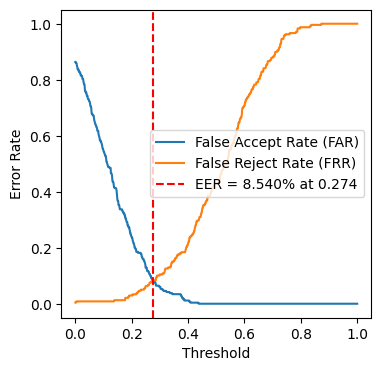

SFace (Baseline) threshold: 0.274


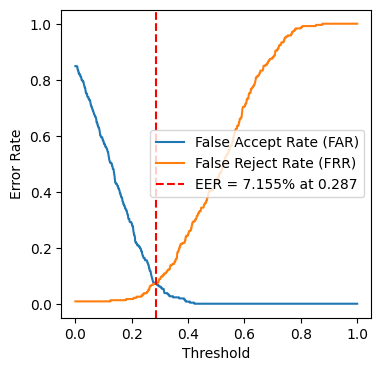

SFace + KD (SFace-OpenCV) threshold: 0.287


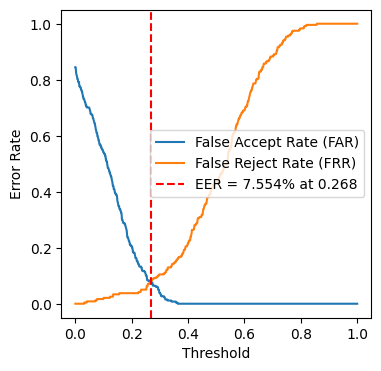

SFace + KD (ArcFace) threshold: 0.268


In [20]:
train_errs = {}

for key, value in results.items():
    genuine_pairs_similarity = value["genuine_pairs_train"]["similarity"]
    imposter_pairs_similarity = value["imposter_pairs_train"]["similarity"]

    threshold, err = display_far_frr(
        genuine_pairs_similarity, imposter_pairs_similarity, key
    )
    print(f"{key} threshold: {threshold:.3f}")
    train_errs[key] = {
        "threshold": threshold,
        "err": err,
    }

### 3.2.2. Testing set


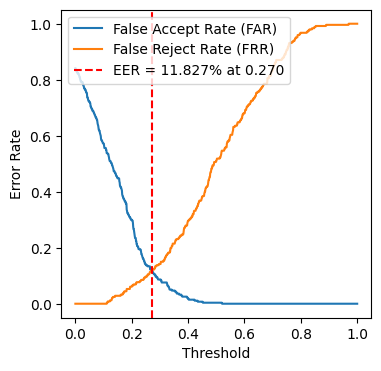

SFace (Baseline) threshold: 0.270


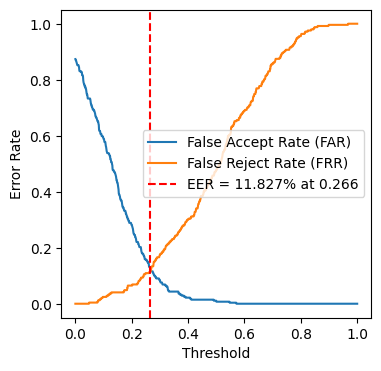

SFace + KD (SFace-OpenCV) threshold: 0.266


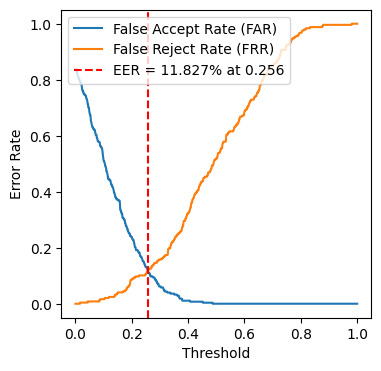

SFace + KD (ArcFace) threshold: 0.256


In [21]:
test_errs = {}

for key, value in results.items():
    genuine_pairs_similarity = value["genuine_pairs_test"]["similarity"]
    imposter_pairs_similarity = value["imposter_pairs_test"]["similarity"]

    threshold, err = display_far_frr(
        genuine_pairs_similarity, imposter_pairs_similarity, key, type="test"
    )
    print(f"{key} threshold: {threshold:.3f}")
    test_errs[key] = {
        "threshold": threshold,
        "err": err,
    }

## 3.3. ROC + AUC


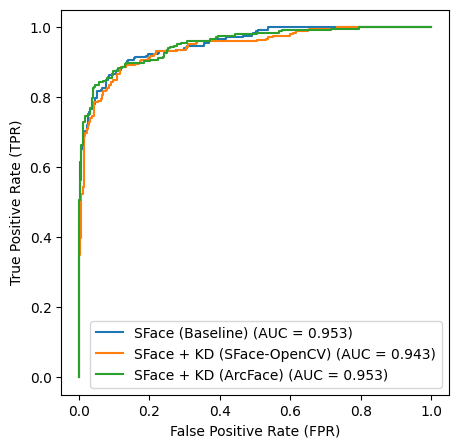

In [22]:
from matplotlib import pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc, roc_curve

fig, ax = plt.subplots()
fig.set_figwidth(5)
fig.set_figheight(5)


def get_name(key):
    mapping = {
        "sface (baseline)": "SFace (Baseline)",
        "sface (baseline) + real": "SFace (Baseline) + fine-tuning",
        "yunet_sface_KD_CE_ArcFace": "SFace + KD (ArcFace)",
        "yunet_sface_KD_CE_03": "SFace + KD (SFace OpenCV)",
    }
    return mapping.get(key, key)


for key, value in results.items():
    y_true = [1] * len(value["genuine_pairs_test"]) + [0] * len(
        value["imposter_pairs_test"]
    )
    y_score = [
        *value["genuine_pairs_test"]["similarity"],
        *value["imposter_pairs_test"]["similarity"],
    ]

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ax.plot(
        fpr,
        tpr,
        label=f"{get_name(key)} (AUC = {auc(fpr, tpr):.3f})",
    )

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.show()

## 3.4. Inference time


In [23]:
import numpy as np

for key, value in results.items():
    inference_time = np.concatenate(
        [
            value["genuine_pairs_test"]["inference_time"].values,
            value["imposter_pairs_test"]["inference_time"].values,
        ]
    ).mean()

    print(f"{key} Inference Time: {inference_time * 1000:.3f} ms")

SFace (Baseline) Inference Time: 87.554 ms
SFace + KD (SFace-OpenCV) Inference Time: 88.845 ms
SFace + KD (ArcFace) Inference Time: 88.696 ms


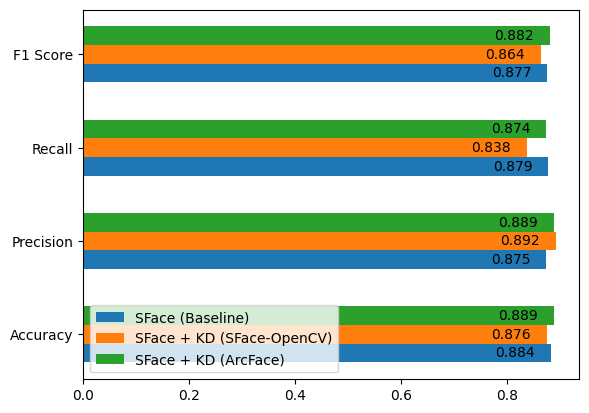

In [24]:
def calc(key: str):
    threshold = train_errs[key]["threshold"]
    genuine_pairs_similarity = results[key]["genuine_pairs_test"]["similarity"]
    imposter_pairs_similarity = results[key]["imposter_pairs_test"]["similarity"]

    tp, tn, fp, fn = 0, 0, 0, 0
    for i in range(len(genuine_pairs_similarity)):
        if genuine_pairs_similarity[i] >= threshold:
            tp += 1
        else:
            fn += 1

    for i in range(len(imposter_pairs_similarity)):
        if imposter_pairs_similarity[i] >= threshold:
            fp += 1
        else:
            tn += 1

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (
        2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    )

    return accuracy, precision, recall, f1_score


species = ("Accuracy", "Precision", "Recall", "F1 Score")
metrics_results = {}
for key, value in results.items():
    metrics_results[get_name(key)] = calc(key)

x = np.arange(len(species))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, ax = plt.subplots()

for attribute, values in metrics_results.items():
    offset = width * multiplier
    rects = ax.barh(
        x + offset,
        values,
        width,
        label=attribute,
    )
    ax.bar_label(rects, padding=-40, fmt="%.3f")
    multiplier += 1

ax.set_yticks(x + width, species)
ax.legend(loc="lower left")
plt.show()

## 3.5. Equal Error Rates


In [25]:
# import numpy as np
# import matplotlib.pyplot as plt

weights = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# err_vals = np.array(
#     [
#         train_errs["SFace + KD (SFace-OpenCV) (0.1)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.2)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.3)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.4)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.5)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.6)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.7)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.8)"]["err"],
#         train_errs["SFace + KD (SFace-OpenCV) (0.9)"]["err"],
#     ]
# )

# plt.plot(weights, err_vals, marker="o")
# plt.xticks(weights)
# plt.xlabel("Hidden Rep Loss Weight")
# plt.ylabel("EER")
# plt.show()

In [26]:
# import numpy as np
# import matplotlib.pyplot as plt

# weights = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# err_vals = np.array(
#     [
#         test_errs["SFace + KD (SFace-OpenCV) (0.1)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.2)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.3)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.4)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.5)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.6)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.7)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.8)"]["err"],
#         test_errs["SFace + KD (SFace-OpenCV) (0.9)"]["err"],
#     ]
# )

# plt.plot(weights, err_vals, marker="o")
# plt.xticks(weights)
# plt.xlabel("Cosine Loss Weight")
# plt.ylabel("Equal Error Rate (EER)")
# plt.show()